In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/haidermaseeh/resume-dataset/Resume dataset.csv
/kaggle/input/datasets/kshitizregmi/jobs-and-job-description/job_title_des.csv


# Semantic Resume-to-Job Alignment Engine using Transformer Embeddings

## Module 1: Environment Setup & Dataset Loading

### Objective

In this module, we will:

- Install all required libraries
- Import necessary packages
- Load the Resume and Job Description datasets
- Inspect the datasets
- Analyze missing values
- Remove unnecessary columns
- Check duplicate records
- Generate descriptive statistics
- Prepare the datasets for preprocessing

This serves as the foundation for the semantic matching pipeline.

In [3]:
# ============================================================
# Install Compatible Library Versions
# ============================================================

!pip -q install -U \
sentence-transformers==2.7.0 \
transformers==4.41.2 \
accelerate==0.31.0 \
huggingface_hub==0.23.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.6/402.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.23.4 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cu

In [4]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import re
import time
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split

# Display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [5]:
# ============================================================
# Load Resume Dataset
# ============================================================

resume_df = pd.read_csv("/kaggle/input/datasets/haidermaseeh/resume-dataset/Resume dataset.csv")

# ============================================================
# Load Job Description Dataset
# ============================================================

jd_df = pd.read_csv("/kaggle/input/datasets/kshitizregmi/jobs-and-job-description/job_title_des.csv")

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


In [6]:
# ============================================================
# Dataset Shapes
# ============================================================

print("=" * 60)
print("Resume Dataset Shape")
print("=" * 60)

print(resume_df.shape)

print("\n")

print("=" * 60)
print("Job Description Dataset Shape")
print("=" * 60)

print(jd_df.shape)

Resume Dataset Shape
(9000, 3)


Job Description Dataset Shape
(2277, 3)


In [7]:
# ============================================================
# Preview Resume Dataset
# ============================================================

resume_df.head()

,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,"Flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis, design, development and im..."
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of JAVA/J2EE Enterprise Application Development experience in Client/Server and web based architecture ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,"Overall 7 years of experience in design and development of User Interface applications, integrating with numerous databases and Client - Server ap..."
3,Java Developers/Architects Resumes,Core Java Developer,"7 + years of experience in Application Analysis, Technical Design, Development, Implementation, Performance Tuning, Testing in all stages of Softw..."
4,Java Developers/Architects Resumes,Android Developer,"With approx 5 years of experience in IT sector in design, development, analysis, implementation and for testing high - end enterprise level Java, ..."


In [8]:
# ============================================================
# Preview Job Description Dataset
# ============================================================

jd_df.head()

,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,"We are looking for hire experts flutter developer. So you are eligible this post then apply your resume.\nJob Types: Full-time, Part-time\nSalary:..."
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ - 04)\nStrong Python experience in API development (REST/RPC).\nExperience working with API Framewor...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n\nResponsibilities\n\nWe are looking for a capable data scientist to join the Analytics team, report..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside of iOS is always a plus\n\niOS experience and generalist engineers with backgrounds in related techno...
4,4,Full Stack Developer,job responsibility full stack engineer – react role make impact petsmart transforming engineering team meet need rapidly changing retail environme...


In [9]:
# ============================================================
# Resume Dataset Information
# ============================================================

resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   category   9000 non-null   object
 1   job_title  9000 non-null   object
 2   Text       9000 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


In [10]:
# ============================================================
# Job Description Dataset Information
# ============================================================

jd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2277 non-null   int64 
 1   Job Title        2277 non-null   object
 2   Job Description  2277 non-null   object
dtypes: int64(1), object(2)
memory usage: 53.5+ KB


In [11]:
# ============================================================
# Missing Values
# ============================================================

print("Resume Dataset Missing Values")

display(resume_df.isnull().sum())

print("\n")

print("Job Description Dataset Missing Values")

display(jd_df.isnull().sum())

Resume Dataset Missing Values


category     0
job_title    0
Text         0
dtype: int64



Job Description Dataset Missing Values


Unnamed: 0         0
Job Title          0
Job Description    0
dtype: int64

In [12]:
# ============================================================
# Duplicate Records
# ============================================================

print("Duplicate Resume Records :", resume_df.duplicated().sum())
print("Duplicate Job Description Records :", jd_df.duplicated().sum())

Duplicate Resume Records : 2156
Duplicate Job Description Records : 0


In [13]:
# ============================================================
# Drop Unnecessary Columns
# ============================================================

if "Unnamed: 0" in jd_df.columns:
    jd_df.drop(columns=["Unnamed: 0"], inplace=True)
print(jd_df.columns)

Index(['Job Title', 'Job Description'], dtype='object')


In [14]:
# ============================================================
# Dataset Quality Report
# ============================================================

print("=" * 60)
print("RESUME DATASET")
print("=" * 60)

print(f"Shape                 : {resume_df.shape}")
print(f"Missing Values        :\n{resume_df.isnull().sum()}\n")
print(f"Duplicate Rows        : {resume_df.duplicated().sum()}")
print(f"Unique Categories     : {resume_df['category'].nunique()}")
print(f"Unique Job Titles     : {resume_df['job_title'].nunique()}")

print("\nTop 10 Categories")
print(resume_df['category'].value_counts().head(10))

print("\nTop 10 Job Titles")
print(resume_df['job_title'].value_counts().head(10))

print("\n")

print("=" * 60)
print("JOB DESCRIPTION DATASET")
print("=" * 60)

print(f"Shape                 : {jd_df.shape}")
print(f"Missing Values        :\n{jd_df.isnull().sum()}\n")
print(f"Duplicate Rows        : {jd_df.duplicated().sum()}")
print(f"Unique Job Titles     : {jd_df['Job Title'].nunique()}")

print("\nTop 10 Job Titles")
print(jd_df['Job Title'].value_counts().head(10))

RESUME DATASET
Shape                 : (9000, 3)
Missing Values        :
category     0
job_title    0
Text         0
dtype: int64

Duplicate Rows        : 2156
Unique Categories     : 9
Unique Job Titles     : 3691

Top 10 Categories
category
Java Developers/Architects Resumes                1000
Web Developer Resumes                             1000
SQL Developers Resumes                            1000
Business Analyst (BA) Resumes                     1000
Network and Systems Administrators Resumes        1000
Datawarehousing, ETL, Informatica Resumes         1000
Business Intelligence, Business Object Resumes    1000
Project Manager Resumes                           1000
Recruiter Resumes                                 1000
Name: count, dtype: int64

Top 10 Job Titles
job_title
Business Analyst             264
Java Developer               166
Informatica Developer        144
QA Analyst                   107
IOS Developer                106
Sr. Informatica Developer    102
UI Devel

In [15]:
# ============================================================
# Create Backup Copies
# ============================================================

resume_raw = resume_df.copy()
jd_raw = jd_df.copy()

print("Backup copies created successfully.")

Backup copies created successfully.


# Module 2 : Data Cleaning and Preprocessing

In this module, we will prepare both datasets for semantic matching by:

- Removing duplicate records
- Dropping unnecessary columns
- Normalizing job titles
- Cleaning resume and job description text
- Computing preprocessing statistics
- Creating clean working datasets

These cleaned datasets will be used throughout the remainder of the project.

In [16]:
# ============================================================
# Remove Exact Duplicate Resume Records
# ============================================================

print("="*60)
print("Removing Duplicate Resume Records")
print("="*60)

rows_before = len(resume_df)

resume_df = resume_df.drop_duplicates().reset_index(drop=True)

rows_after = len(resume_df)

duplicates_removed = rows_before - rows_after

print(f"Rows Before Cleaning : {rows_before}")
print(f"Rows After Cleaning  : {rows_after}")
print(f"Duplicates Removed   : {duplicates_removed}")

Removing Duplicate Resume Records
Rows Before Cleaning : 9000
Rows After Cleaning  : 6844
Duplicates Removed   : 2156


In [17]:
# ============================================================
# Remove Duplicate Job Descriptions
# ============================================================

rows_before = len(jd_df)

jd_df = jd_df.drop_duplicates().reset_index(drop=True)

rows_after = len(jd_df)

print(f"Duplicate JDs Removed : {rows_before - rows_after}")

Duplicate JDs Removed : 0


In [18]:
# ============================================================
# Rename Columns
# ============================================================

resume_df.rename(columns={"Text":"resume_text"}, inplace=True)

jd_df.rename(columns={"Job Title":"job_title", "Job Description":"job_description"}, inplace=True)

print("Updated Resume Columns")
print(resume_df.columns)

print("\nUpdated JD Columns")
print(jd_df.columns)

Updated Resume Columns
Index(['category', 'job_title', 'resume_text'], dtype='object')

Updated JD Columns
Index(['job_title', 'job_description'], dtype='object')


In [19]:
# ============================================================
# General Text Cleaning Function
# ============================================================

def clean_text(text):
    """
    Cleans raw text for NLP processing.

    Steps:
    - Convert to lowercase
    - Remove URLs
    - Remove email addresses
    - Remove extra whitespace
    - Remove unwanted symbols
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", " ", text)

    # remove emails
    text = re.sub(r"\S+@\S+", " ", text)

    # remove unwanted characters
    text = re.sub(r"[^a-zA-Z0-9+#./ ]", " ", text)

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [20]:
# ============================================================
# Clean Resume Text
# ============================================================

resume_df["resume_text"] = resume_df["resume_text"].apply(clean_text)

print("Resume text cleaned successfully.")

Resume text cleaned successfully.


In [21]:
# ============================================================
# Clean Job Description
# ============================================================

jd_df["job_description"] = jd_df["job_description"].apply(clean_text)

print("Job descriptions cleaned successfully.")

Job descriptions cleaned successfully.


In [22]:
# ============================================================
# Job Title Normalization
# ============================================================

def normalize_job_title(title):

    title = title.lower()

    title = re.sub(r"\bsr\b|\bsenior\b", "", title)
    title = re.sub(r"\bjr\b|\bjunior\b", "", title)
    title = re.sub(r"\blead\b", "", title)
    title = re.sub(r"\bprincipal\b", "", title)
    title = re.sub(r"\bassociate\b", "", title)

    title = re.sub(r"\s+", " ", title)

    return title.strip()

In [23]:
def clean_job_title(title):

    title = str(title).lower()

    # Remove punctuation
    title = re.sub(r"[^a-zA-Z0-9\s/+]", " ", title)

    # Remove multiple spaces
    title = re.sub(r"\s+", " ", title)

    return title.strip()

In [24]:
# ============================================================
# Apply Job Title Normalization
# ============================================================

resume_df["normalized_title"] = (resume_df["job_title"].apply(clean_job_title).apply(normalize_job_title))

jd_df["normalized_title"] = (
    jd_df["job_title"]
    .apply(clean_job_title)
    .apply(normalize_job_title)
)

print("Job titles normalized successfully.")

Job titles normalized successfully.


In [25]:
# ============================================================
# Resume Preview
# ============================================================

resume_df[[
    "job_title",
    "normalized_title",
    "resume_text"
]].head()

,job_title,normalized_title,resume_text
0,Java Developer,java developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...
1,Sr. Java/J2EE Developer,java/j2ee developer,senior java developer with around 7+ years of java/j2ee enterprise application development experience in client/server and web based architecture ...
2,Sr. iOS Developer,ios developer,overall 7 years of experience in design and development of user interface applications integrating with numerous databases and client server appli...
3,Core Java Developer,core java developer,7 + years of experience in application analysis technical design development implementation performance tuning testing in all stages of software d...
4,Android Developer,android developer,with approx 5 years of experience in it sector in design development analysis implementation and for testing high end enterprise level java window...


In [26]:
# ============================================================
# JD Preview
# ============================================================

jd_df[[
    "job_title",
    "normalized_title",
    "job_description"
]].head()

,job_title,normalized_title,job_description
0,Flutter Developer,flutter developer,we are looking for hire experts flutter developer. so you are eligible this post then apply your resume. job types full time part time salary 20 0...
1,Django Developer,django developer,python/django developer/lead job code pdj 04 strong python experience in api development rest/rpc . experience working with api frameworks django/...
2,Machine Learning,machine learning,data scientist contractor bangalore in responsibilities we are looking for a capable data scientist to join the analytics team reporting locally i...
3,iOS Developer,ios developer,job description strong framework outside of ios is always a plus ios experience and generalist engineers with backgrounds in related technologies ...
4,Full Stack Developer,full stack developer,job responsibility full stack engineer react role make impact petsmart transforming engineering team meet need rapidly changing retail environment...


In [27]:
# ============================================================
# Final Preprocessing Report
# ============================================================

print("="*60)
print("PREPROCESSING REPORT")
print("="*60)

print(f"Final Resume Count      : {len(resume_df)}")
print(f"Final JD Count          : {len(jd_df)}")

print(f"\nUnique Resume Titles    : {resume_df['normalized_title'].nunique()}")
print(f"Unique JD Titles        : {jd_df['normalized_title'].nunique()}")

print(f"\nAverage Resume Length   : {resume_df['resume_text'].str.split().str.len().mean():.2f} words")
print(f"Average JD Length       : {jd_df['job_description'].str.split().str.len().mean():.2f} words")

print("="*60)

PREPROCESSING REPORT
Final Resume Count      : 6844
Final JD Count          : 2277

Unique Resume Titles    : 3009
Unique JD Titles        : 15

Average Resume Length   : 1591.58 words
Average JD Length       : 278.12 words


# Module 3 : Semantic Text Chunking

## Objective

Transformer models have a maximum input length and perform better on
coherent text segments rather than entire documents.

In this module we split resumes and job descriptions into overlapping
semantic chunks using a sliding window approach.

Each chunk will later be embedded using MPNet and indexed in FAISS for
fast semantic retrieval.

In [28]:
# ============================================================
# Import Libraries
# ============================================================

import nltk
from nltk.tokenize import sent_tokenize

nltk.download("punkt")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
# ============================================================
# Semantic Chunk Generator
# ============================================================

def create_chunks(text,
                  chunk_size=5,
                  overlap=2):
    """
    Create overlapping chunks from sentences.

    Parameters
    ----------
    chunk_size : number of sentences per chunk

    overlap : number of overlapping sentences
    """

    if pd.isna(text):
        return []

    sentences = sent_tokenize(text)
    chunks = []
    step = chunk_size - overlap

    for i in range(0, len(sentences), step):
        chunk = " ".join(sentences[i:i+chunk_size])
        if len(chunk.strip()) > 0:

            chunks.append(chunk)
    return chunks

In [30]:
# ============================================================
# Create Resume Chunks
# ============================================================

resume_df["chunks"] = resume_df["resume_text"].apply(create_chunks)

print("Resume chunking completed.")

Resume chunking completed.


In [31]:
# ============================================================
# Create JD Chunks
# ============================================================

jd_df["chunks"] = jd_df["job_description"].apply(create_chunks)

print("Job Description chunking completed.")

Job Description chunking completed.


In [32]:
# ============================================================
# Convert Chunks into Structured Dictionaries
# ============================================================

def create_chunk_objects(chunk_list):
    """
    Converts a list of text chunks into a list of dictionaries.

    Example:
    [
        {"chunk_id":0, "text":"..."},
        {"chunk_id":1, "text":"..."}
    ]
    """

    return [
        {
            "chunk_id": idx,
            "text": chunk
        }
        for idx, chunk in enumerate(chunk_list)
    ]

In [33]:
# ============================================================
# Create Structured Resume Chunks
# ============================================================

resume_df["chunk_objects"] = resume_df["chunks"].apply(create_chunk_objects)

print("Structured Resume Chunks Created Successfully.")

Structured Resume Chunks Created Successfully.


In [34]:
# ============================================================
# Create Structured JD Chunks
# ============================================================

jd_df["chunk_objects"] = jd_df["chunks"].apply(create_chunk_objects)

print("Structured Job Description Chunks Created Successfully.")

Structured Job Description Chunks Created Successfully.


In [35]:
# ============================================================
# Preview Structured Resume Chunks
# ============================================================

resume_df.loc[0, "chunk_objects"][:3]

[{'chunk_id': 0,
  'text': 'flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and implementation of n tier architecture based applications business to business applications business to client based applications distributed components internet/intranet applications. areas of expertise include analysis design and development of applications using jee/j2ee technologies including java servlets jsp ejb jms jdbc jndi jta web services soap jaxb jax rpc jax ws xml and xsd. good knowledge on object oriented programming oop analysis and design ooad concepts and designing experience using staruml rational rose to develop uml or design artifacts like class diagrams sequence diagrams and use case realization. worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xslt oracle sql and mvc architecture.'},
 {'chunk_id': 1,
  't

In [36]:
# ============================================================
# Flatten Resume Chunks
# ============================================================

resume_chunk_records = []

for resume_id, row in resume_df.iterrows():

    for chunk in row["chunk_objects"]:

        resume_chunk_records.append({

            "resume_id": resume_id,

            "chunk_id": chunk["chunk_id"],

            "job_title": row["job_title"],

            "normalized_title": row["normalized_title"],

            "chunk_text": chunk["text"]

        })

resume_chunks_df = pd.DataFrame(resume_chunk_records)

print("Resume Chunk DataFrame Shape :", resume_chunks_df.shape)

resume_chunks_df.head()

Resume Chunk DataFrame Shape : (184367, 5)


,resume_id,chunk_id,job_title,normalized_title,chunk_text
0,0,0,Java Developer,java developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...
1,0,1,Java Developer,java developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...
2,0,2,Java Developer,java developer,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...
3,0,3,Java Developer,java developer,highly proficient in using frameworks like struts hibernate spring and design patterns such as session fa ade front controller data access object ...
4,0,4,Java Developer,java developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...


In [37]:
# ============================================================
# Flatten Job Description Chunks
# ============================================================

jd_chunk_records = []

for jd_id, row in jd_df.iterrows():

    for chunk in row["chunk_objects"]:

        jd_chunk_records.append({

            "jd_id": jd_id,

            "chunk_id": chunk["chunk_id"],

            "job_title": row["job_title"],

            "normalized_title": row["normalized_title"],

            "chunk_text": chunk["text"]

        })

jd_chunks_df = pd.DataFrame(jd_chunk_records)

print("JD Chunk DataFrame Shape :", jd_chunks_df.shape)

jd_chunks_df.head()

JD Chunk DataFrame Shape : (8278, 5)


,jd_id,chunk_id,job_title,normalized_title,chunk_text
0,0,0,Flutter Developer,flutter developer,we are looking for hire experts flutter developer. so you are eligible this post then apply your resume. job types full time part time salary 20 0...
1,1,0,Django Developer,django developer,python/django developer/lead job code pdj 04 strong python experience in api development rest/rpc . experience working with api frameworks django/...
2,1,1,Django Developer,django developer,ability to effectively handle multiple tasks with a high level of accuracy and attention to detail. good verbal and written communication skills. ...
3,1,2,Django Developer,django developer,json experience preferred. good knowledge in automated unit testing using pyunit.
4,2,0,Machine Learning,machine learning,data scientist contractor bangalore in responsibilities we are looking for a capable data scientist to join the analytics team reporting locally i...


In [38]:
# ============================================================
# Verify Chunk DataFrames
# ============================================================

print("=" * 60)
print("Resume Chunk DataFrame")
print("=" * 60)

print(resume_chunks_df.head())

print()

print("=" * 60)
print("JD Chunk DataFrame")
print("=" * 60)

print(jd_chunks_df.head())

Resume Chunk DataFrame
   resume_id  chunk_id       job_title normalized_title  \
0          0         0  Java Developer   java developer   
1          0         1  Java Developer   java developer   
2          0         2  Java Developer   java developer   
3          0         3  Java Developer   java developer   
4          0         4  Java Developer   java developer   

                                                                                                                                              chunk_text  
0  flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...  
1  worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...  
2  good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...  
3 

In [39]:
# ============================================================
# Chunk Statistics
# ============================================================

resume_df["num_chunks"] = resume_df["chunks"].apply(len)
jd_df["num_chunks"] = jd_df["chunks"].apply(len)
print("="*60)
print("Resume Statistics")
print("="*60)
print(resume_df["num_chunks"].describe())
print()
print("="*60)
print("JD Statistics")
print("="*60)
print(jd_df["num_chunks"].describe())

Resume Statistics
count    6844.000000
mean       26.938486
std        16.856674
min         1.000000
25%        14.000000
50%        26.000000
75%        37.000000
max       145.000000
Name: num_chunks, dtype: float64

JD Statistics
count    2277.000000
mean        3.635485
std         3.193073
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        26.000000
Name: num_chunks, dtype: float64


In [40]:
# ============================================================
# Preview Structured Resume Chunks
# ============================================================

sample = resume_df.iloc[0]["chunk_objects"]

for chunk in sample:

    print("=" * 60)
    print(f"Chunk ID : {chunk['chunk_id']}")
    print("=" * 60)
    print(chunk["text"])
    print()

Chunk ID : 0
flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and implementation of n tier architecture based applications business to business applications business to client based applications distributed components internet/intranet applications. areas of expertise include analysis design and development of applications using jee/j2ee technologies including java servlets jsp ejb jms jdbc jndi jta web services soap jaxb jax rpc jax ws xml and xsd. good knowledge on object oriented programming oop analysis and design ooad concepts and designing experience using staruml rational rose to develop uml or design artifacts like class diagrams sequence diagrams and use case realization. worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xslt oracle sql and mvc architecture.

Chunk ID : 1
worked in web application

# Module 4 : Transformer Embedding Generation

## Objective

In this module, we convert every resume chunk and job description chunk into
high-dimensional semantic vectors using the Transformer model:

**sentence-transformers/all-mpnet-base-v2**

These embeddings capture semantic meaning beyond simple keyword matching.

The generated embeddings will later be used for:

- FAISS Indexing
- Semantic Retrieval
- Alignment Matrix
- ATS Score Calculation
- Streamlit Deployment

In [41]:
# ============================================================
# Import Libraries
# ============================================================

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm
import numpy as np

In [42]:
# ============================================================
# Load MPNet Model
# ============================================================

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model...")

model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

model.eval()

print()

print("="*60)
print("Model Loaded Successfully")
print("="*60)

print(f"Model : {MODEL_NAME}")
print(f"Device : {device}")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loading model...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


Model Loaded Successfully
Model : sentence-transformers/all-mpnet-base-v2
Device : cuda


In [43]:
# ============================================================
# Mean Pooling
# ============================================================

def mean_pooling(model_output, attention_mask):

    token_embeddings = model_output.last_hidden_state

    input_mask_expanded = (attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float())

    return torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(
        input_mask_expanded.sum(dim=1), min=1e-9)

In [44]:
# ============================================================
# Generate Embeddings
# ============================================================

def generate_embeddings(texts, batch_size=32, max_length=256):

    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):

        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt")

        encoded = {k:v.to(device)

            for k,v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            pooled = mean_pooling(outputs, encoded["attention_mask"])

            pooled = F.normalize(pooled, p=2, dim=1)

        embeddings.append(pooled.cpu().numpy())

    embeddings = np.vstack(embeddings)

    return embeddings

In [45]:
# ============================================================
# Generate Resume Embeddings
# ============================================================

resume_embeddings = generate_embeddings(resume_chunks_df["chunk_text"].tolist())
print()
print("Resume Embeddings Shape")
print(resume_embeddings.shape)

  0%|          | 0/5762 [00:00<?, ?it/s]


Resume Embeddings Shape
(184367, 768)


In [46]:
# ============================================================
# Generate Job Description Embeddings
# ============================================================

jd_embeddings = generate_embeddings(jd_chunks_df["chunk_text"].tolist())

print()
print("JD Embeddings Shape")
print(jd_embeddings.shape)

  0%|          | 0/259 [00:00<?, ?it/s]


JD Embeddings Shape
(8278, 768)


In [47]:
# ============================================================
# Attach Embeddings
# ============================================================

resume_chunks_df["embedding"] = list(resume_embeddings)
jd_chunks_df["embedding"] = list(jd_embeddings)
print("Embeddings attached successfully.")

Embeddings attached successfully.


In [48]:
# ============================================================
# Verify Embedding Dimensions
# ============================================================

print("="*60)
print("Resume Embeddings")
print("="*60)
print(resume_embeddings.shape)
print()
print("="*60)
print("JD Embeddings")
print("="*60)
print(jd_embeddings.shape)
print()
print("Embedding Dimension :", resume_embeddings.shape[1])

Resume Embeddings
(184367, 768)

JD Embeddings
(8278, 768)

Embedding Dimension : 768


In [49]:
# ============================================================
# Inspect One Embedding
# ============================================================

resume_chunks_df.head()

,resume_id,chunk_id,job_title,normalized_title,chunk_text,embedding
0,0,0,Java Developer,java developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,"[0.07033836, -0.029295938, -0.04428341, -0.034574624, 0.035355058, -0.010597539, -0.011181958, 0.009370726, 0.0013108052, -0.04906964, 0.001416578..."
1,0,1,Java Developer,java developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,"[0.05510503, -0.0041954457, -0.015071479, -0.044804014, 0.037160896, -0.010279257, -0.009100644, 0.040551476, 0.031920232, -0.024225956, -0.029932..."
2,0,2,Java Developer,java developer,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...,"[0.049559128, -0.041476615, -0.03313657, -0.034530915, 0.061287668, -0.0037458937, -0.020481322, 0.015050506, 0.03546702, -0.012201154, -0.0229591..."
3,0,3,Java Developer,java developer,highly proficient in using frameworks like struts hibernate spring and design patterns such as session fa ade front controller data access object ...,"[0.040887497, -0.05528837, -0.05658123, -0.04356872, 0.05461427, -0.010535941, -0.029874511, 0.009848589, 0.005692573, -0.036446184, 0.037815515, ..."
4,0,4,Java Developer,java developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,"[0.05939074, -0.03868635, -0.03876984, -0.061848737, 0.044591207, -0.0053018336, -0.012092267, 0.0032572234, -0.0016475215, -0.029682903, 0.050662..."


In [50]:
# ============================================================
# Save Embeddings
# ============================================================

np.save("resume_embeddings.npy", resume_embeddings)

np.save("jd_embeddings.npy", jd_embeddings)

print("Embedding files saved successfully.")

Embedding files saved successfully.


In [51]:
# ============================================================
# Save Processed DataFrames
# ============================================================

resume_chunks_df.to_pickle("resume_chunks.pkl")
jd_chunks_df.to_pickle("jd_chunks.pkl")
print("Processed data saved successfully.")

Processed data saved successfully.


# Module 5 : FAISS Semantic Index Construction

## Objective

Searching every job description chunk against every resume chunk is computationally expensive.

To enable fast semantic retrieval, we build a FAISS (Facebook AI Similarity Search)
index over the Job Description embeddings.

FAISS performs Approximate Nearest Neighbor (ANN) search, allowing us to retrieve
the most semantically similar job description chunks in milliseconds.

The index will later power:

- Semantic Resume Matching
- ATS Score Calculation
- Streamlit Search

In [52]:
# ============================================================
# Install FAISS
# ============================================================

!pip -q install faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 69.7 MB/s eta 0:00:00:00:0100:01


In [53]:
# ============================================================
# Import Libraries
# ============================================================

import faiss
import numpy as np

In [54]:
# ============================================================
# Verify Embeddings
# ============================================================

print("Resume Embeddings :", resume_embeddings.shape)
print("JD Embeddings     :", jd_embeddings.shape)

Resume Embeddings : (184367, 768)
JD Embeddings     : (8278, 768)


In [55]:
# ============================================================
# Convert Embeddings to float32
# ============================================================

resume_embeddings = resume_embeddings.astype(np.float32)

jd_embeddings = jd_embeddings.astype(np.float32)

In [56]:
# ============================================================
# Build FAISS Index
# ============================================================

embedding_dimension = jd_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(embedding_dimension)

print("Index Created Successfully")

Index Created Successfully


In [57]:
# ============================================================
# Add JD Embeddings to FAISS
# ============================================================

faiss_index.add(jd_embeddings)

print("Total Indexed Chunks :", faiss_index.ntotal)

Total Indexed Chunks : 8278


In [58]:
# ============================================================
# Test Retrieval
# ============================================================

TOP_K = 5

query_vector = resume_embeddings[0].reshape(1, -1)

scores, indices = faiss_index.search(query_vector, TOP_K)

In [59]:
# ============================================================
# Display Search Results
# ============================================================

for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
    print("=" * 80)
    print(f"Rank       : {rank}")
    print(f"Similarity : {score:.4f}")
    print(f"JD ID      : {jd_chunks_df.iloc[idx]['jd_id']}")
    print(f"Chunk ID   : {jd_chunks_df.iloc[idx]['chunk_id']}")
    print()
    print(jd_chunks_df.iloc[idx]["chunk_text"][:500])
    print()

Rank       : 1
Similarity : 0.8338
JD ID      : 936
Chunk ID   : 0

job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets struts webservices spring hibernate java script jquery and ajax. good knowledge in oracle possess advanced knowledge of object oriented design and development ooa/ood and the j2ee framework and data architectures. experience working with and applying design patterns to solve problems. demonstrate strong written and oral communication skills. hands on ex

Rank       : 2
Similarity : 0.8288
JD ID      : 2244
Chunk ID   : 5

8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui development tools like web developer and firebug. 10. working knowledge on xml technologies jaxp dom and sax parsers . 11. hands on experience with databases including oracle pl/sql and microsoft sql involving stored p

In [60]:
# ============================================================
# Save FAISS Index
# ============================================================

faiss.write_index(faiss_index, "jd_faiss.index")
print("FAISS Index Saved Successfully.")

FAISS Index Saved Successfully.


In [ ]:
# ============================================================
# Load Saved FAISS Index
# ============================================================

loaded_index = faiss.read_index("jd_faiss.index")

print("Loaded Index Size :", loaded_index.ntotal)

# Module 6 : Semantic Resume-to-Job Alignment Matrix

## Objective

Instead of comparing entire resumes with entire job descriptions, we compare
each resume chunk against the most semantically similar job description chunks.

This produces an Alignment Matrix that explains:

- Which resume experience matched which job requirement
- Similarity score for each match
- Top matching evidence
- Foundation for ATS scoring

The alignment matrix forms the explainable core of the semantic resume matching system.

In [75]:
# ============================================================
# Retrieve Top-K Matching JD Chunks
# ============================================================

def retrieve_top_matches(resume_embedding, top_k=5):

    scores, indices = faiss_index.search(resume_embedding.reshape(1, -1), top_k)
    return scores[0], indices[0]

In [77]:
# ============================================================
# Build Semantic Alignment Matrix
# ============================================================

alignment_records = []

TOP_K = 5

for idx, row in resume_chunks_df.iterrows():

    scores, indices = retrieve_top_matches(
        resume_embeddings[idx],
        TOP_K
    )

    for rank, (score, jd_idx) in enumerate(zip(scores, indices), start=1):

        alignment_records.append({

            "resume_id": row["resume_id"],

            "resume_chunk_id": row["chunk_id"],

            "resume_job_title": row["job_title"],

            "resume_chunk": row["chunk_text"],

            "jd_id": jd_chunks_df.iloc[jd_idx]["jd_id"],

            "jd_chunk_id": jd_chunks_df.iloc[jd_idx]["chunk_id"],

            "jd_job_title": jd_chunks_df.iloc[jd_idx]["job_title"],

            "jd_chunk": jd_chunks_df.iloc[jd_idx]["chunk_text"],

            "similarity": float(score),

            "rank": rank

        })

In [78]:
# ============================================================
# Alignment Matrix DataFrame
# ============================================================

alignment_df = pd.DataFrame(alignment_records)

print("="*60)
print("Alignment Matrix Created")
print("="*60)

print(alignment_df.shape)

alignment_df.head()

Alignment Matrix Created
(921835, 10)


,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
0,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.833801,1
1,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.828818,2
2,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,84,3,Software Engineer,collaborate with other developers to select appropriate design solutions. communicate effectively with individuals of varying technical abilities ...,0.797377,3
3,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,591,4,Java Developer,also engage with client in requirement gathering status update on work uat and be the key partner in the overall engagement. qualifications minimu...,0.795901,4
4,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,573,1,Java Developer,we provide the tools and resources to help you be successful and our culture fosters an environment in which idea sharing and collaboration is ess...,0.790974,5


In [80]:
# ============================================================
# Top Semantic Matches
# ============================================================

alignment_df.sort_values(by="similarity", ascending=False).head(20)

,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
847281,6345,4,UI Developer,ability to write clear well documented well commented and efficient code for web development. experience with user acceptance testing uat and acce...,1245,3,Backend Developer,strong understanding of the web development cycle and programming techniques and tools. focus on efficiency user experience and process improvemen...,0.936892,2
847280,6345,4,UI Developer,ability to write clear well documented well commented and efficient code for web development. experience with user acceptance testing uat and acce...,2085,3,Backend Developer,strong understanding of the web development cycle and programming techniques and tools. focus on efficiency user experience and process improvemen...,0.936892,1
50170,321,0,Mac OSX and iOS Application Developer,over 7 years experience as software development engineer including 5 years experience as ios developer. strong knowledge of iphone/ipad/mac applic...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.930742,1
885675,6597,0,Mac OSX and iOS Application Developer,over 7 years experience as software development engineer including 5 years experience as ios developer. strong knowledge of iphone/ipad/mac applic...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.930742,1
86900,556,1,IOS Developer,good experience on objective c and swift programming language. extensive experience in iphone ipod touch application development. worked extensive...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.926312,1
818655,6163,1,IOS Developer,good experience on objective c and swift programming language. extensive experience in iphone ipod touch application development. worked extensive...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.926312,1
20925,134,0,Sr. Java Developer,around 7.5 years of experience in analysis design and development in diversified areas of client server distributed and web applications using jav...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.921761,1
75375,485,0,Java Developer,around 7.5 years of experience in analysis design and development in diversified areas of client server distributed and web applications using jav...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.921761,1
868995,6489,1,IOS Developer,expertise in design and development in c c++ java objective c and swift. solid exposure to ooad design patterns data structures and algorithms. wo...,762,0,iOS Developer,proficient with swift 3 and onwards objective c and cocoa touch. experience with core data and other frameworks. experience in google map firebase...,0.920033,1
88915,570,1,IOS Developer,expertise in design and development in c c++ java objective c and swift. solid exposure to ooad design patterns data structures and algorithms. wo...,762,0,iOS Developer,proficient with swift 3 and onwards objective c and cocoa touch. experience with core data and other frameworks. experience in google map firebase...,0.920033,1


In [81]:
# ============================================================
# Resume Match Statistics
# ============================================================

resume_scores = (alignment_df.groupby("resume_id")["similarity"].agg([
        "mean", "max", "min"]).reset_index())

resume_scores.head()

,resume_id,mean,max,min
0,0,0.651710,0.863653,0.482857
1,1,0.708444,0.880798,0.469190
2,2,0.700264,0.844549,0.572533
3,3,0.684215,0.879019,0.508854
4,4,0.645654,0.857430,0.404383


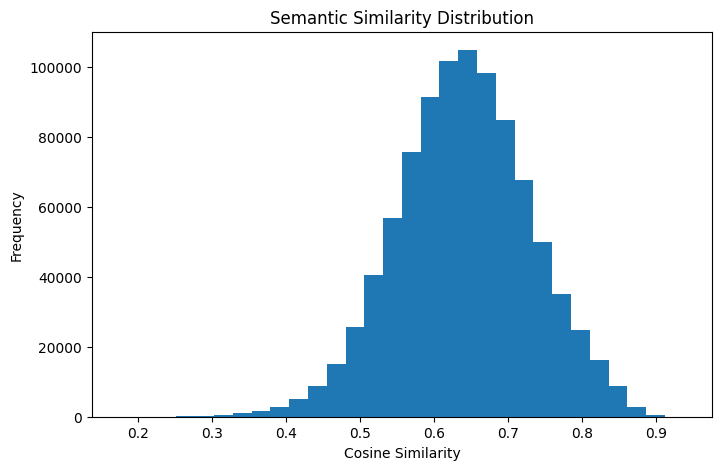

In [82]:
# ============================================================
# Similarity Distribution
# ============================================================

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(alignment_df["similarity"], bins=30)
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Semantic Similarity Distribution")
plt.show()

In [83]:
# ============================================================
# Example Resume Alignment
# ============================================================

sample_resume = 0
sample = alignment_df[alignment_df["resume_id"] == sample_resume].sort_values("similarity", ascending=False)
sample.head(10)

,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
5,0,1,Java Developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.863653,1
6,0,1,Java Developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.855959,2
10,0,2,Java Developer,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.851820,1
20,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,233,3,Java Developer,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.844930,1
21,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,564,2,Software Engineer,job description technical hands on expertise in core java and webtechnologies hands on expertise in working with spring framework rest/soap web se...,0.839564,2
22,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,853,1,DevOps Engineer,enjoy working in a team environment excellent verbal and written communication skills strong programming/scripting and troubleshooting skills back...,0.834372,3
0,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.833801,1
23,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,1990,5,Software Engineer,ability to create execute and maintain scripts and tools for various testing frameworks. desire to interact with many different software developme...,0.832538,4
24,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,560,2,Java Developer,must have to be considered as fit candidate bachelor s degree in computer science or related field 4+ years experience in java application develop...,0.830965,5
1,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.828818,2


In [84]:
# ============================================================
# Save Alignment Matrix
# ============================================================

alignment_df.to_pickle(

    "alignment_matrix.pkl"

)

print("Alignment Matrix Saved Successfully.")

Alignment Matrix Saved Successfully.


# Module 7 : Intelligent ATS Score Calculation

## Objective

The Alignment Matrix contains similarity scores between resume chunks and job
description chunks.

This module aggregates these chunk-level similarities into an interpretable
Resume-to-Job ATS Compatibility Score.

Instead of relying on keyword matching, the score is computed from semantic
similarity between the applicant's experience and the job requirements.

In [85]:
# ============================================================
# Best Match per Resume Chunk
# ============================================================

best_matches = (alignment_df.groupby(
        ["resume_id", "resume_chunk_id"])["similarity"].max().reset_index())

best_matches.head()

,resume_id,resume_chunk_id,similarity
0,0,0,0.833801
1,0,1,0.863653
2,0,2,0.851820
3,0,3,0.825416
4,0,4,0.844930


In [86]:
# ============================================================
# Compute Resume-Level ATS Metrics
# ============================================================

ats_metrics = (best_matches.groupby("resume_id")["similarity"].agg(

        Mean_Similarity="mean",

        Max_Similarity="max",

        Min_Similarity="min",

        Std_Similarity="std",

        Number_of_Chunks="count"

    ).reset_index())

ats_metrics.head()

,resume_id,Mean_Similarity,Max_Similarity,Min_Similarity,Std_Similarity,Number_of_Chunks
0,0,0.676519,0.863653,0.550868,0.086926,37
1,1,0.732072,0.880798,0.487586,0.097016,20
2,2,0.725411,0.844549,0.603997,0.068362,25
3,3,0.707892,0.879019,0.572474,0.085315,20
4,4,0.670300,0.857430,0.445445,0.120114,28


In [87]:
# ============================================================
# High Confidence Matches
# ============================================================

SIMILARITY_THRESHOLD = 0.75

high_matches = (best_matches["similarity"] >= SIMILARITY_THRESHOLD)

high_match_counts = (best_matches.assign(high_match=high_matches)
    .groupby("resume_id")["high_match"].sum().reset_index())

high_match_counts.rename(columns={
        "high_match":"High_Confidence_Matches"}, inplace=True)

In [88]:
# ============================================================
# Merge ATS Metrics
# ============================================================

ats_metrics = ats_metrics.merge(high_match_counts, on="resume_id")

ats_metrics.head()

,resume_id,Mean_Similarity,Max_Similarity,Min_Similarity,Std_Similarity,Number_of_Chunks,High_Confidence_Matches
0,0,0.676519,0.863653,0.550868,0.086926,37,7
1,1,0.732072,0.880798,0.487586,0.097016,20,9
2,2,0.725411,0.844549,0.603997,0.068362,25,7
3,3,0.707892,0.879019,0.572474,0.085315,20,5
4,4,0.670300,0.857430,0.445445,0.120114,28,8


In [89]:
# ============================================================
# Coverage Score
# ============================================================

ats_metrics["Coverage"] = (ats_metrics["High_Confidence_Matches"] / ats_metrics["Number_of_Chunks"])

In [90]:
# ============================================================
# Final ATS Score
# ============================================================

ats_metrics["ATS_Score"] = (0.70 * ats_metrics["Mean_Similarity"] + 0.30 * ats_metrics["Coverage"])

ats_metrics["ATS_Score"] *= 100

ats_metrics["ATS_Score"] = ats_metrics["ATS_Score"].round(2)

In [91]:
# ============================================================
# ATS Grade
# ============================================================

def assign_grade(score):

    if score >= 85:
        return "Excellent"

    elif score >= 70:
        return "Good"

    elif score >= 55:
        return "Average"

    else:
        return "Needs Improvement"

ats_metrics["Grade"] = (

    ats_metrics["ATS_Score"]

    .apply(assign_grade)

)

In [92]:
# ============================================================
# Preview ATS Results
# ============================================================

ats_metrics.head(10)

,resume_id,Mean_Similarity,Max_Similarity,Min_Similarity,Std_Similarity,Number_of_Chunks,High_Confidence_Matches,Coverage,ATS_Score,Grade
0,0,0.676519,0.863653,0.550868,0.086926,37,7,0.189189,53.03,Needs Improvement
1,1,0.732072,0.880798,0.487586,0.097016,20,9,0.450000,64.75,Average
2,2,0.725411,0.844549,0.603997,0.068362,25,7,0.280000,59.18,Average
3,3,0.707892,0.879019,0.572474,0.085315,20,5,0.250000,57.05,Average
4,4,0.670300,0.857430,0.445445,0.120114,28,8,0.285714,55.49,Average
5,5,0.682319,0.891705,0.514756,0.088542,70,14,0.200000,53.76,Needs Improvement
6,6,0.687533,0.898188,0.497451,0.106678,41,12,0.292683,56.91,Average
7,7,0.681145,0.894953,0.579422,0.076069,32,4,0.125000,51.43,Needs Improvement
8,8,0.654486,0.860571,0.533325,0.094606,26,4,0.153846,50.43,Needs Improvement
9,9,0.788176,0.824538,0.751813,0.051424,2,2,1.000000,85.17,Excellent


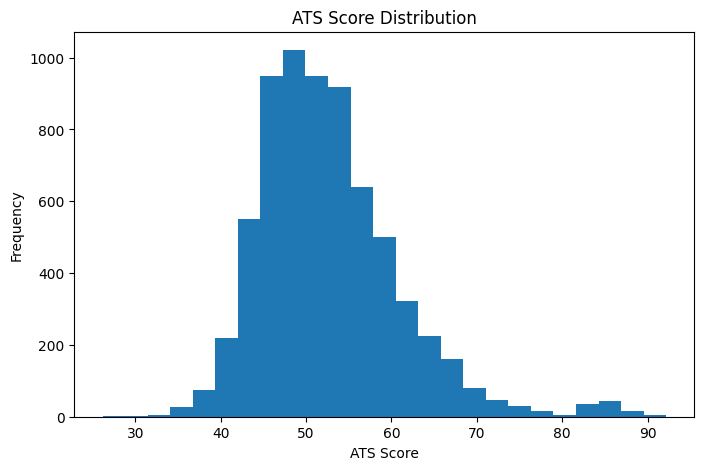

In [93]:
# ============================================================
# ATS Score Distribution
# ============================================================
plt.figure(figsize=(8,5))

plt.hist(ats_metrics["ATS_Score"], bins=25)

plt.xlabel("ATS Score")

plt.ylabel("Frequency")

plt.title("ATS Score Distribution")

plt.show()

In [94]:
# ============================================================
# Top ATS Scores
# ============================================================

ats_metrics.sort_values(

    "ATS_Score",

    ascending=False

).head(20)

,resume_id,Mean_Similarity,Max_Similarity,Min_Similarity,Std_Similarity,Number_of_Chunks,High_Confidence_Matches,Coverage,ATS_Score,Grade
6479,6479,0.888326,0.888326,0.888326,NaN,1,1,1.0,92.18,Excellent
2823,2823,0.858053,0.858053,0.858053,NaN,1,1,1.0,90.06,Excellent
2586,2586,0.858053,0.858053,0.858053,NaN,1,1,1.0,90.06,Excellent
946,946,0.851684,0.851684,0.851684,NaN,1,1,1.0,89.62,Excellent
4363,4363,0.844564,0.877643,0.811485,0.046780,2,2,1.0,89.12,Excellent
5150,5150,0.839380,0.839380,0.839380,NaN,1,1,1.0,88.76,Excellent
3954,3954,0.838922,0.902276,0.790450,0.047105,4,4,1.0,88.72,Excellent
2555,2555,0.837678,0.837678,0.837678,NaN,1,1,1.0,88.64,Excellent
1005,1005,0.831364,0.831364,0.831364,NaN,1,1,1.0,88.20,Excellent
2315,2315,0.826880,0.826880,0.826880,NaN,1,1,1.0,87.88,Excellent


In [95]:
# ============================================================
# Save ATS Results
# ============================================================

ats_metrics.to_pickle(

    "ats_scores.pkl"

)

print("ATS Scores Saved Successfully.")

ATS Scores Saved Successfully.


# Module 8 : Explainable ATS Analysis

## Objective

An ATS score alone is not very useful unless users understand why they received
that score.

This module generates an explainable report by identifying:

- Best matching resume chunks
- Best matching job description chunks
- High-confidence matches
- Weak matches

This improves transparency and provides actionable feedback to applicants.

In [96]:
# ============================================================
# Top Semantic Matches
# ============================================================

top_matches = (alignment_df.sort_values("similarity", ascending=False))

top_matches.head(10)

,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
847281,6345,4,UI Developer,ability to write clear well documented well commented and efficient code for web development. experience with user acceptance testing uat and acce...,1245,3,Backend Developer,strong understanding of the web development cycle and programming techniques and tools. focus on efficiency user experience and process improvemen...,0.936892,2
847280,6345,4,UI Developer,ability to write clear well documented well commented and efficient code for web development. experience with user acceptance testing uat and acce...,2085,3,Backend Developer,strong understanding of the web development cycle and programming techniques and tools. focus on efficiency user experience and process improvemen...,0.936892,1
50170,321,0,Mac OSX and iOS Application Developer,over 7 years experience as software development engineer including 5 years experience as ios developer. strong knowledge of iphone/ipad/mac applic...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.930742,1
885675,6597,0,Mac OSX and iOS Application Developer,over 7 years experience as software development engineer including 5 years experience as ios developer. strong knowledge of iphone/ipad/mac applic...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.930742,1
86900,556,1,IOS Developer,good experience on objective c and swift programming language. extensive experience in iphone ipod touch application development. worked extensive...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.926312,1
818655,6163,1,IOS Developer,good experience on objective c and swift programming language. extensive experience in iphone ipod touch application development. worked extensive...,437,0,iOS Developer,working experience in ios development. proficient with swift and cocoa touch. have published one or more ios apps in the app store. experience wor...,0.926312,1
20925,134,0,Sr. Java Developer,around 7.5 years of experience in analysis design and development in diversified areas of client server distributed and web applications using jav...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.921761,1
75375,485,0,Java Developer,around 7.5 years of experience in analysis design and development in diversified areas of client server distributed and web applications using jav...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.921761,1
868995,6489,1,IOS Developer,expertise in design and development in c c++ java objective c and swift. solid exposure to ooad design patterns data structures and algorithms. wo...,762,0,iOS Developer,proficient with swift 3 and onwards objective c and cocoa touch. experience with core data and other frameworks. experience in google map firebase...,0.920033,1
88915,570,1,IOS Developer,expertise in design and development in c c++ java objective c and swift. solid exposure to ooad design patterns data structures and algorithms. wo...,762,0,iOS Developer,proficient with swift 3 and onwards objective c and cocoa touch. experience with core data and other frameworks. experience in google map firebase...,0.920033,1


In [97]:
# ============================================================
# Best Match for Every Resume Chunk
# ============================================================

best_alignment = (alignment_df.sort_values("similarity", ascending=False).groupby(["resume_id", "resume_chunk_id"])
    .first().reset_index())

best_alignment.head()

,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
0,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.833801,1
1,0,1,Java Developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.863653,1
2,0,2,Java Developer,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.851820,1
3,0,3,Java Developer,highly proficient in using frameworks like struts hibernate spring and design patterns such as session fa ade front controller data access object ...,233,3,Java Developer,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.825416,1
4,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,233,3,Java Developer,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.844930,1


In [98]:
# ============================================================
# Strong Matches
# ============================================================

STRONG_THRESHOLD = 0.80

strong_matches = best_alignment[

    best_alignment["similarity"] >= STRONG_THRESHOLD

]

print("Strong Matches :", len(strong_matches))

strong_matches.head()

Strong Matches : 12082


,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
0,0,0,Java Developer,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.833801,1
1,0,1,Java Developer,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,936,0,Java Developer,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.863653,1
2,0,2,Java Developer,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...,2244,5,Backend Developer,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.851820,1
3,0,3,Java Developer,highly proficient in using frameworks like struts hibernate spring and design patterns such as session fa ade front controller data access object ...,233,3,Java Developer,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.825416,1
4,0,4,Java Developer,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,233,3,Java Developer,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.844930,1


In [99]:
# ============================================================
# Weak Matches
# ============================================================

WEAK_THRESHOLD = 0.60

weak_matches = best_alignment[

    best_alignment["similarity"] < WEAK_THRESHOLD

]

print("Weak Matches :", len(weak_matches))

weak_matches.head()

Weak Matches : 41096


,resume_id,resume_chunk_id,resume_job_title,resume_chunk,jd_id,jd_chunk_id,jd_job_title,jd_chunk,similarity,rank
8,0,8,Java Developer,used java swing for few components in accordance with swt application with multithreading environment with concurrency and java collections. used ...,1163,12,Software Engineer,java build tools and best practices e.g. unit testing test automation continuous integration etc. . extra credit exposure to hadoop technologies a...,0.573178,1
9,0,9,Java Developer,written junit test cases with mockito while performing unit testing. used tortoise svn as source control tool. worked with qa team during various ...,1371,0,JavaScript Developer,job description javaserver pages jsp and servletsweb technologies like html css javascript and jquerymarkup languages like xml and jsonobject orie...,0.570998,1
11,0,11,Java Developer,developed the application using hibernate and spring framework. developed presentation layer using spring mvc and used annotation based mapping to...,1909,0,Java Developer,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.578201,1
12,0,12,Java Developer,followed soa creating rest web services using spring. developed rich user interface using html5 jsf jsp xslt and css3. configured jboss applicatio...,1909,0,Java Developer,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.597739,1
13,0,13,Java Developer,used hibernate to communicate with the database mapping the entities to the tables and corresponding columns in the database by using hibernate an...,1909,0,Java Developer,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.595543,1


In [100]:
# ============================================================
# Explainable Report for One Resume
# ============================================================

resume_id = 0

report = (

    best_alignment[

        best_alignment["resume_id"] == resume_id

    ]

    .sort_values(

        "similarity",

        ascending=False

    )

)

report[
    [
        "resume_chunk",
        "jd_chunk",
        "similarity"
    ]
].head(10)

,resume_chunk,jd_chunk,similarity
1,worked in web application development using html dhtml css uml and javascript. experience in client side technologies such as javabeans jms xml xs...,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.863653
2,good knowledge and sound experience working with mvc framework like struts1.3 2.0 orm frameworks like hibernate jpa and ioc frameworks like spring...,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.851820
4,proficient in developing unit testing integration testing and container testing components with good knowledge on testing frame works and testing ...,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.844930
0,flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis design development and impl...,job nature 3 5 years experience in java j2ee development extensive technical experience and development expertise in core java j2ee jsp servlets s...,0.833801
3,highly proficient in using frameworks like struts hibernate spring and design patterns such as session fa ade front controller data access object ...,experience with test driven development unit testing frameworks . ability to effectively communicate and deliver technical information to business...,0.825416
5,technical skills languages c c++ java sql pl/sql unix shell script html xml java/j2ee technologies servlets jsp ejb jms jdbc jndi jta jpa xml xsd ...,8. experienced in writing maven scripts to build and deploy java applications. 9. expertise in javascript ajax and ability to analyze using ui dev...,0.790345
27,environment java j2ee struts 2.3 jsp servlets html javascript ajax xml xslt css pl/sql web services eclipse svn oracle 10g application server and ...,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.756187
17,was responsible for updating the defects status in a daily based qa status meeting. environment java 1.6 core java/j2ee ood rest web services spri...,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.746712
22,responsible for deploying the entire application on weblogic application server 9.2. used junit for writing several test cases and extensively inv...,responsibilities for this profile are shared as below work experience as a senior java developer or similar role. having good knowledge of any rdb...,0.729184
26,involved in unit and manual testing of the application. used jira for issue tracking and svn as a version control. installed oracle 10g database a...,java developer schaumburg il are you currently working with java javascript spring junit jboss ibm message queuing and infosphere looking for a pr...,0.713144


In [101]:
# ============================================================
# Save Report
# ============================================================

best_alignment.to_pickle("best_alignment.pkl")
print("Explainable alignment report saved successfully.")

Explainable alignment report saved successfully.
